# Text Recognition

## 1. Setup & Imports

In [1]:
!pip install torch torchvision

In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import Dataset, DataLoader
import numpy as np
import random
import matplotlib.pyplot as plt

## 2. Dataset

`SequenceMNIST` builds synthetic multi-digit sequences by concatenating random MNIST digit images horizontally. It accepts a `train` flag to draw from MNIST's own train or test split — used below to build a genuinely held-out test set, not just a second sample of the same training data.

In [3]:
class SequenceMNIST(Dataset):
    def __init__(self, length=10000, seq_len=5, train=True):
        self.transform = transforms.ToTensor()
        mnist = datasets.MNIST(root='./data', train=train, download=True)
        self.data = []
        self.targets = []
        for _ in range(length):
            indices = random.sample(range(len(mnist)), seq_len)
            images = [self.transform(mnist[i][0]) for i in indices]  # <-- ubah ke tensor
            labels = [mnist[i][1] for i in indices]
            img_concat = torch.cat(images, dim=2)  # hasil: [1, 28, 28 * seq_len]
            self.data.append(img_concat)
            self.targets.append(torch.tensor(labels, dtype=torch.long))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx], self.targets[idx], len(self.targets[idx])

## 3. Model Architecture

In [4]:
class CRNN(nn.Module):
    def __init__(self, num_classes=11):  # 10 digits + CTC blank
        super(CRNN, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2, 2)
        )
        self.rnn = nn.LSTM(input_size=128 * 7, hidden_size=128, num_layers=1,
                           bidirectional=True, batch_first=True)
        self.fc = nn.Linear(256, num_classes)  # BiLSTM output dim is 2x hidden

    def forward(self, x):
        x = self.cnn(x)  # [B, C, H, W] -> [B, 128, 7, W/4]
        b, c, h, w = x.size()
        x = x.permute(0, 3, 1, 2).contiguous().view(b, w, -1)  # [B, W, C*H]
        x, _ = self.rnn(x)
        x = self.fc(x)
        return x.log_softmax(2)  # For CTC

## 4. Data Loading

In [5]:
def collate_fn(batch):
    imgs, labels, label_lengths = zip(*batch)
    imgs = torch.stack(imgs)
    labels = torch.cat(labels)
    label_lengths = torch.tensor(label_lengths)
    input_lengths = torch.full(size=(len(batch),), fill_value=imgs.shape[-1] // 4, dtype=torch.long)
    return imgs, labels, input_lengths, label_lengths

In [6]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_dataset = SequenceMNIST(length=10000, seq_len=5, train=True)
test_dataset = SequenceMNIST(length=2000, seq_len=5, train=False)  # held-out: built from MNIST's test split

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, collate_fn=collate_fn)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=collate_fn)

print(f"Train sequences: {len(train_dataset)} | Test sequences (held-out): {len(test_dataset)}")

100%|██████████| 9.91M/9.91M [00:00<00:00, 18.6MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 467kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.13MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 11.7MB/s]


Train sequences: 10000 | Test sequences (held-out): 2000


## 5. Training

Test loss (on the held-out set, no backprop) is tracked alongside train loss every epoch, so the training curve below actually shows generalization, not just training-set loss going down.

In [7]:
model = CRNN().to(device)
criterion = nn.CTCLoss(blank=10, zero_infinity=True)
optimizer = optim.Adam(model.parameters(), lr=1e-3)

history = {'train_loss': [], 'test_loss': []}

for epoch in range(10):
    model.train()
    epoch_loss = 0
    for imgs, labels, input_lens, label_lens in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        output = model(imgs)  # [B, T, C]
        output = output.permute(1, 0, 2)  # for CTC: [T, B, C]
        loss = criterion(output, labels, input_lens, label_lens)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_loss = epoch_loss / len(train_loader)

    model.eval()
    test_epoch_loss = 0
    with torch.no_grad():
        for imgs, labels, input_lens, label_lens in test_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            output = model(imgs).permute(1, 0, 2)
            loss = criterion(output, labels, input_lens, label_lens)
            test_epoch_loss += loss.item()
    test_loss = test_epoch_loss / len(test_loader)

    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)
    print(f"Epoch {epoch+1}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}")

Epoch 1, Train Loss: 2.0011, Test Loss: 0.5838
Epoch 2, Train Loss: 0.3011, Test Loss: 0.1850
Epoch 3, Train Loss: 0.1380, Test Loss: 0.1102
Epoch 4, Train Loss: 0.0867, Test Loss: 0.0765
Epoch 5, Train Loss: 0.0599, Test Loss: 0.0732
Epoch 6, Train Loss: 0.0431, Test Loss: 0.0590
Epoch 7, Train Loss: 0.0308, Test Loss: 0.0472
Epoch 8, Train Loss: 0.0242, Test Loss: 0.0432
Epoch 9, Train Loss: 0.0171, Test Loss: 0.0409
Epoch 10, Train Loss: 0.0138, Test Loss: 0.0437


## 6. Training Curves

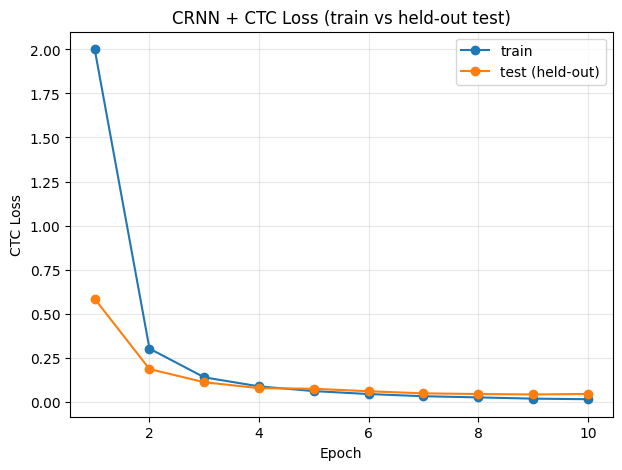

In [8]:
plt.figure(figsize=(7, 5))
plt.plot(range(1, len(history['train_loss'])+1), history['train_loss'], marker='o', label='train')
plt.plot(range(1, len(history['test_loss'])+1), history['test_loss'], marker='o', label='test (held-out)')
plt.title('CRNN + CTC Loss (train vs held-out test)')
plt.xlabel('Epoch')
plt.ylabel('CTC Loss')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## 7. Quantitative Evaluation: Sequence Accuracy & CER

A single matching sample is a nice sanity check, but it isn't a benchmark. This section decodes every sequence in the held-out test set and reports two numbers: exact-match sequence accuracy, and Character Error Rate (CER) — the total edit distance between predictions and targets, divided by the total number of target characters.

In [9]:
import torch.nn.functional as F

def decode(predictions, blank=10):
    probs = F.softmax(predictions, dim=2)
    max_probs = probs.argmax(2).detach().cpu().numpy()  # [T, B]
    results = []
    for seq in max_probs.T:  # [B, T] -> iterate per sample
        decoded = []
        prev = -1
        for idx in seq:
            if idx != prev and idx != blank:
                decoded.append(str(idx))
            prev = idx
        results.append(''.join(decoded))
    return results

def levenshtein(a, b):
    dp = [[0] * (len(b) + 1) for _ in range(len(a) + 1)]
    for i in range(len(a) + 1):
        dp[i][0] = i
    for j in range(len(b) + 1):
        dp[0][j] = j
    for i in range(1, len(a) + 1):
        for j in range(1, len(b) + 1):
            cost = 0 if a[i-1] == b[j-1] else 1
            dp[i][j] = min(dp[i-1][j] + 1, dp[i][j-1] + 1, dp[i-1][j-1] + cost)
    return dp[-1][-1]

model.eval()
correct, total_edits, total_chars = 0, 0, 0
n_samples = 0

with torch.no_grad():
    for imgs, labels, input_lens, label_lens in test_loader:
        imgs = imgs.to(device)
        output = model(imgs).permute(1, 0, 2)
        preds = decode(output)

        idx = 0
        for i, l in enumerate(label_lens):
            target = ''.join(str(x.item()) for x in labels[idx: idx + l])
            idx += l
            pred = preds[i]
            if pred == target:
                correct += 1
            total_edits += levenshtein(pred, target)
            total_chars += len(target)
            n_samples += 1

seq_accuracy = correct / n_samples
cer = total_edits / total_chars
print(f"Held-out test set size: {n_samples} sequences")
print(f"Sequence accuracy (exact match): {seq_accuracy:.4f}")
print(f"Character Error Rate (CER): {cer:.4f}")

Held-out test set size: 2000 sequences
Sequence accuracy (exact match): 0.9345
Character Error Rate (CER): 0.0137


## 8. Qualitative Check

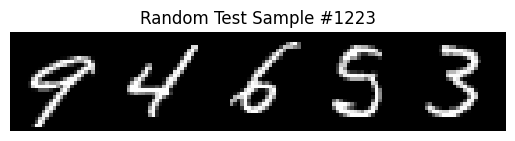

Target   : 94653
Prediksi : 94653


In [10]:
import random

# Test Random Sample — drawn from the held-out test set, not the training data
model.eval()
with torch.no_grad():
    idx = random.randint(0, len(test_dataset) - 1)
    sample, label, _ = test_dataset[idx]

    plt.imshow(sample.squeeze(), cmap='gray')
    plt.title(f"Random Test Sample #{idx}")
    plt.axis('off')
    plt.show()

    sample_input = sample.unsqueeze(0).to(device)
    output = model(sample_input).permute(1, 0, 2)
    prediction = decode(output)[0]

    print("Target   :", ''.join(str(x.item()) for x in label))
    print("Prediksi :", prediction)

## 9. Save Model to Drive

In [11]:
# Mount Google Drive untuk menyimpan model hasil training
from google.colab import drive
drive.mount('/content/drive')

import os
MODEL_DIR = '/content/drive/MyDrive/text-recognition-crnn-ctc'
os.makedirs(MODEL_DIR, exist_ok=True)

Mounted at /content/drive


In [12]:
torch.save(model.state_dict(), f'{MODEL_DIR}/crnn_mnist.pt')

In [13]:
model = CRNN().to(device)
model.load_state_dict(torch.load(f'{MODEL_DIR}/crnn_mnist.pt', map_location=device))
model.eval()

CRNN(
  (cnn): Sequential(
    (0): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (rnn): LSTM(896, 128, batch_first=True, bidirectional=True)
  (fc): Linear(in_features=256, out_features=11, bias=True)
)

---

*Hands-on material: rubythalib.ai*